In [53]:
# 顺序和倒序的打分结果平均
# -*- coding: utf-8 -*-
import os
import pandas as pd

RESULT_ROOT = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

FILE_A = os.path.join(RESULT_ROOT, "Forward", "3_final_scores_forward.csv")
FILE_B = os.path.join(RESULT_ROOT, "Reverse", "3_final_scores_reverse.csv")
OUT_DIR = RESULT_ROOT
os.makedirs(OUT_DIR, exist_ok=True)

OUT_FILE = os.path.join(OUT_DIR, "3_final_scores_avg.csv")
OUT_COMPARE_FILE = os.path.join(OUT_DIR, "3_final_scores_side_by_side.csv")

METRIC_COLUMNS = [
    "Detail_Specificity",
    "Scientific_Grounding",
    "Mechanistic_Explanation",
    "Organization_Format_Quality",
    "Anchor_Alignment",
    "Internal_Consistency",
    "Research_Utility",
]

WEIGHTS = {
    "Detail_Specificity": 0.18,
    "Scientific_Grounding": 0.20,
    "Mechanistic_Explanation": 0.16,
    "Organization_Format_Quality": 0.08,
    "Anchor_Alignment": 0.18,
    "Internal_Consistency": 0.08,
    "Research_Utility": 0.12,
}

EXTRA_NUMERIC_COLUMNS = [
    "JudgeParseOK(%)",
    "InvalidAnswer(%)",
    "ScoredItems",
    "Coverage(%)",
]

#PREFERRED_MODEL_ORDER = [
#    "BEAVER_NoQualityLoop",
#    "Constrained_DeepSeek-V3",
#    "Raw_DeepSeek-V3",
#    "Constrained_DeepSeek-R1",
#    "Raw_DeepSeek-R1",
#    "Constrained_Qwen-Max",
#    "Raw_Qwen-Max",
#    "Constrained_Kimi",
#    "Raw_Kimi",
#]

# 现在的模型顺序（只保留5个）
PREFERRED_MODEL_ORDER = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-V3",
    "Raw_DeepSeek-R1",
]

EXCLUDE_MODEL_KEYWORDS = ["Qwen", "Kimi"]

def filter_excluded_models(df: pd.DataFrame) -> pd.DataFrame:
    """Strictly keep only PREFERRED_MODEL_ORDER and remove Kimi/Qwen rows.

    这样即使 avg CSV 里还残留 Kimi/Qwen，或后面 cell 直接读取旧 CSV，
    绘图时也只会保留 5 个指定模型。
    """
    if "Model" not in df.columns:
        return df.copy()

    out = df.copy()

    # 1) 强制只保留目标 5 个模型，比仅按关键词排除更稳。
    out = out[out["Model"].astype(str).isin(PREFERRED_MODEL_ORDER)].copy()

    # 2) 双保险：排除任何名称中包含 Qwen/Kimi 的模型。
    pattern = "|".join(EXCLUDE_MODEL_KEYWORDS)
    mask = ~out["Model"].astype(str).str.contains(pattern, case=False, regex=True, na=False)
    out = out.loc[mask].copy()

    return out


def read_score_csv(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件: {path}")
    df = pd.read_csv(path)
    if "Model" not in df.columns:
        raise ValueError(f"文件缺少 Model 列: {path}")
    return filter_excluded_models(df).copy()


def safe_avg(a, b):
    a_nan = pd.isna(a)
    b_nan = pd.isna(b)
    if a_nan and b_nan:
        return pd.NA
    if a_nan:
        return b
    if b_nan:
        return a
    return (float(a) + float(b)) / 2.0


def main():
    df_a = read_score_csv(FILE_A)
    df_b = read_score_csv(FILE_B)

    merged = pd.merge(df_a, df_b, on="Model", how="outer", suffixes=("_4_12", "_5_12"))

    # 保存并排对照，方便你回看差异
    merged.to_csv(OUT_COMPARE_FILE, index=False, encoding="utf-8-sig")

    out = pd.DataFrame()
    out["Model"] = merged["Model"]

    # 平均 7 个维度
    for col in METRIC_COLUMNS:
        col_a = f"{col}_4_12"
        col_b = f"{col}_5_12"
        if col_a in merged.columns or col_b in merged.columns:
            out[col] = [safe_avg(a, b) for a, b in zip(merged.get(col_a), merged.get(col_b))]

    # Overall 用平均后的 7 维重新计算，避免直接平均 Overall 带来的舍入误差
    out["Overall"] = 0.0
    for col, w in WEIGHTS.items():
        if col in out.columns:
            out["Overall"] = out["Overall"] + out[col].fillna(0).astype(float) * w

    # 额外数值列做平均
    for col in EXTRA_NUMERIC_COLUMNS:
        col_a = f"{col}_4_12"
        col_b = f"{col}_5_12"
        if col_a in merged.columns or col_b in merged.columns:
            out[col] = [safe_avg(a, b) for a, b in zip(merged.get(col_a), merged.get(col_b))]

    # 保留两边原始 Overall 方便核对
    if "Overall_4_12" in merged.columns:
        out["Overall_from_4_12"] = merged["Overall_4_12"]
    if "Overall_5_12" in merged.columns:
        out["Overall_from_5_12"] = merged["Overall_5_12"]

    # 数值格式
    for col in METRIC_COLUMNS + ["Overall", "JudgeParseOK(%)", "InvalidAnswer(%)", "Coverage(%)", "Overall_from_4_12", "Overall_from_5_12"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").round(2)

    if "ScoredItems" in out.columns:
        out["ScoredItems"] = pd.to_numeric(out["ScoredItems"], errors="coerce").round(1)

    # 模型排序
    order_map = {m: i for i, m in enumerate(PREFERRED_MODEL_ORDER)}
    out["_order"] = out["Model"].map(order_map).fillna(999)
    out = out.sort_values(by=["_order", "Overall"], ascending=[True, False]).drop(columns=["_order"]).reset_index(drop=True)

    out.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

    print("\n=== Averaged final scores ===")
    print(out.to_string(index=False))
    print(f"\n已保存平均结果: {OUT_FILE}")
    print(f"已保存并排对照: {OUT_COMPARE_FILE}")


if __name__ == "__main__":
    main()



=== Averaged final scores ===
                  Model  Detail_Specificity  Scientific_Grounding  Mechanistic_Explanation  Organization_Format_Quality  Anchor_Alignment  Internal_Consistency  Research_Utility  Overall  JudgeParseOK(%)  InvalidAnswer(%)  ScoredItems  Coverage(%)  Overall_from_4_12  Overall_from_5_12
   BEAVER_NoQualityLoop                9.41                  8.23                     9.16                         8.30              8.58                  8.62              8.90     8.77            100.0               0.0        111.0        100.0               8.99               8.55
Constrained_DeepSeek-V3                8.81                  7.52                     9.09                         8.81              7.80                  9.12              8.70     8.42            100.0               0.0        111.0        100.0               8.26               8.59
Constrained_DeepSeek-R1                8.62                  7.49                     8.83                     

,Model,Detail_Specificity,Scientific_Grounding,Mechanistic_Explanation,Organization_Format_Quality,Anchor_Alignment,Internal_Consistency,Research_Utility,Overall,JudgeParseOK(%),InvalidAnswer(%),ScoredItems,Coverage(%),Overall_from_4_12,Overall_from_5_12
0,BEAVER_NoQualityLoop,9.41,8.23,9.16,8.30,8.58,8.62,8.90,8.77,100.0,0.0,111.0,100.0,8.99,8.55
1,Constrained_DeepSeek-V3,8.81,7.52,9.09,8.81,7.80,9.12,8.70,8.42,100.0,0.0,111.0,100.0,8.26,8.59
2,Constrained_DeepSeek-R1,8.62,7.49,8.83,8.56,7.82,8.87,8.34,8.27,100.0,0.0,111.0,100.0,7.93,8.61
3,Raw_DeepSeek-V3,7.98,8.04,7.72,8.49,8.86,8.78,7.85,8.20,100.0,0.0,111.0,100.0,8.14,8.26
4,Raw_DeepSeek-R1,7.86,7.76,7.54,8.28,8.59,8.61,7.64,7.99,100.0,0.0,111.0,100.0,7.95,8.02


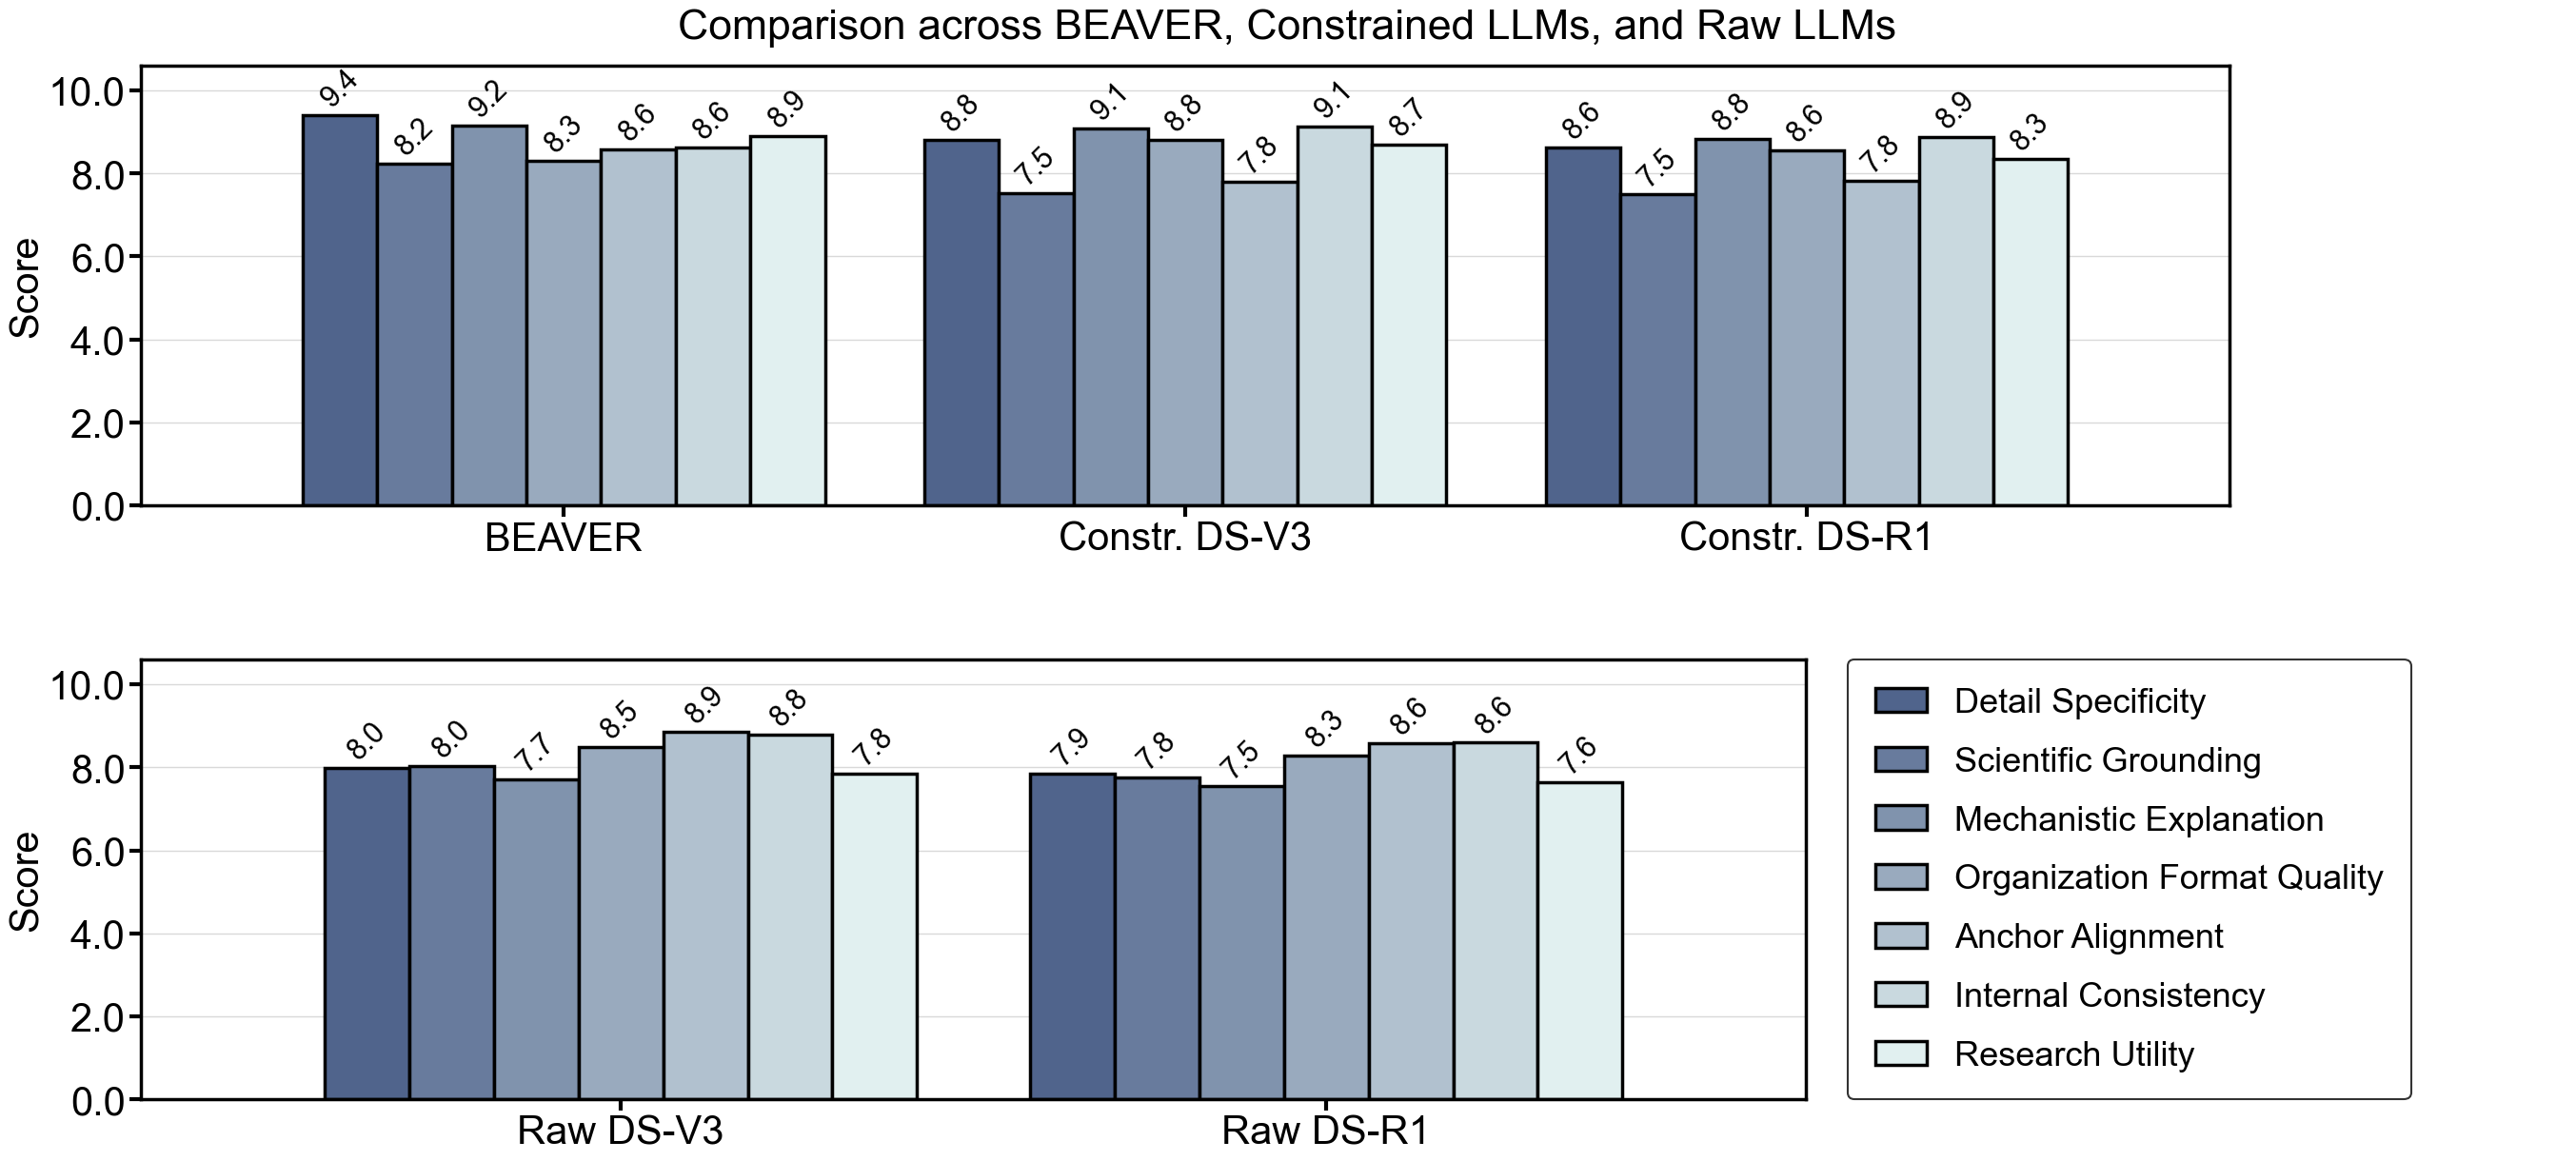

已保存: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\Dimension_scores_grouped_two_rows_fixedwidth_style2.png


In [55]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 如果你在 Jupyter 里，建议保留这一句
%matplotlib inline

# =========================
# ===== 全局字号设置 =====
# =========================
FS_TITLE = 32
FS_LABEL = 30
FS_TICK = 30
FS_LEGEND = 26
FS_LEGEND_TITLE = 26
FS_ANNOT = 22   # 柱子顶部数字字号

# =========================
# ===== 全局风格设置 =====
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 3
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["ytick.major.width"] = 3
plt.rcParams["xtick.major.size"] = 8.5
plt.rcParams["ytick.major.size"] = 8.5

# =========================
# ===== 布局可调参数 =====
# =========================
ROT_X = 0
FIGSIZE_GROUPED = (26, 13)
FW = "normal"

# 图例整体位置（保留，不实际使用）
LEGEND_X = 0.5
LEGEND_Y = -0.40

# 图例内部排布（保留）
LEGEND_NCOL = 4
LEGEND_COLSPACING = 1.6
LEGEND_HANDLELENGTH = 1.5
LEGEND_BORDERPAD = 0.8

# 子图留白（保留）
BOTTOM_GROUPED = 0.52

# =========================
# ===== 路径设置 =====
# =========================
RESULT_ROOT = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

CSV_FILE = os.path.join(RESULT_ROOT, "3_final_scores_avg.csv")

OUT_DIR = os.path.join(RESULT_ROOT, "plots")
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# ===== 列设置 =====
# =========================
METRIC_COLUMNS = [
    "Detail_Specificity",
    "Scientific_Grounding",
    "Mechanistic_Explanation",
    "Organization_Format_Quality",
    "Anchor_Alignment",
    "Internal_Consistency",
    "Research_Utility",
]

PRETTY_METRIC_NAMES = {
    "Detail_Specificity": "Detail Specificity",
    "Scientific_Grounding": "Scientific Grounding",
    "Mechanistic_Explanation": "Mechanistic Explanation",
    "Organization_Format_Quality": "Organization Format Quality",
    "Anchor_Alignment": "Anchor Alignment",
    "Internal_Consistency": "Internal Consistency",
    "Research_Utility": "Research Utility",
}

# PREFERRED_MODEL_ORDER = [
#     "BEAVER_NoQualityLoop",
#     "Constrained_DeepSeek-V3",
#     "Raw_DeepSeek-V3",
#     "Constrained_DeepSeek-R1",
#     "Raw_DeepSeek-R1",
#     "Constrained_Qwen-Max",
#     "Raw_Qwen-Max",
#     "Constrained_Kimi",
#     "Raw_Kimi",
# ]

# 现在的模型顺序（只保留5个）
PREFERRED_MODEL_ORDER = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-V3",
    "Raw_DeepSeek-R1",
]


MODEL_LABEL_MAP = {
    "BEAVER_NoQualityLoop": "BEAVER",
    "Constrained_DeepSeek-V3": "Constr. DS-V3",
    "Raw_DeepSeek-V3": "Raw DS-V3",
    "Constrained_DeepSeek-R1": "Constr. DS-R1",
    "Raw_DeepSeek-R1": "Raw DS-R1",
    "Constrained_Qwen-Max": "Constr. Qwen",
    "Raw_Qwen-Max": "Raw Qwen",
    "Constrained_Kimi": "Constr. Kimi",
    "Raw_Kimi": "Raw Kimi",
}

# =========================
# ===== 配色：深 -> 浅 =====
# =========================
DARK_RGB = (80, 100, 140)
LIGHT_RGB = (225, 240, 240)

# =========================
# ===== 工具函数 =====
# =========================
def rgb255_to_01(rgb):
    return np.array(rgb) / 255.0

def make_gradient_colors(n, start_rgb=DARK_RGB, end_rgb=LIGHT_RGB):
    start = rgb255_to_01(start_rgb)
    end = rgb255_to_01(end_rgb)

    if n == 1:
        return [tuple(start)]

    colors = []
    for t in np.linspace(0, 1, n):
        c = start * (1 - t) + end * t
        colors.append(tuple(c))
    return colors

def prettify_model_name(name):
    return MODEL_LABEL_MAP.get(name, name)

def style_spines(ax, lw=2.5):
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(lw)

EXCLUDE_MODEL_KEYWORDS = ["Qwen", "Kimi"]

def filter_excluded_models(df: pd.DataFrame) -> pd.DataFrame:
    """Strictly keep only PREFERRED_MODEL_ORDER and remove Kimi/Qwen rows.

    这样即使 avg CSV 里还残留 Kimi/Qwen，或后面 cell 直接读取旧 CSV，
    绘图时也只会保留 5 个指定模型。
    """
    if "Model" not in df.columns:
        return df.copy()

    out = df.copy()

    # 1) 强制只保留目标 5 个模型，比仅按关键词排除更稳。
    out = out[out["Model"].astype(str).isin(PREFERRED_MODEL_ORDER)].copy()

    # 2) 双保险：排除任何名称中包含 Qwen/Kimi 的模型。
    pattern = "|".join(EXCLUDE_MODEL_KEYWORDS)
    mask = ~out["Model"].astype(str).str.contains(pattern, case=False, regex=True, na=False)
    out = out.loc[mask].copy()

    return out

def load_data(csv_file):
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"找不到文件: {csv_file}")

    df = pd.read_csv(csv_file, encoding="utf-8-sig")
    df = filter_excluded_models(df)

    if "Model" not in df.columns or "Overall" not in df.columns:
        raise ValueError("CSV 至少需要包含 Model 和 Overall 列")

    for col in METRIC_COLUMNS + ["Overall"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    order_map = {m: i for i, m in enumerate(PREFERRED_MODEL_ORDER)}
    df["_order"] = df["Model"].map(order_map).fillna(999)
    df = df.sort_values(["_order"]).drop(columns=["_order"]).reset_index(drop=True)

    return df

# =========================
# ===== 主绘图函数 =====
# =========================
def plot_metric_grouped_bar_two_rows(df, out_dir, show_in_notebook=True):
    TOP_MODEL_ORDER = [
        "BEAVER_NoQualityLoop",
        "Constrained_DeepSeek-V3",
        "Constrained_DeepSeek-R1",
    ]

    BOTTOM_MODEL_ORDER = [
        "Raw_DeepSeek-V3",
        "Raw_DeepSeek-R1",
    ]

    metric_cols_exist = [c for c in METRIC_COLUMNS if c in df.columns]
    if len(metric_cols_exist) == 0:
        print("未找到7维指标列，跳过。")
        return

    def reorder_by_list(df_in, model_order):
        tmp = df_in[df_in["Model"].isin(model_order)].copy()
        order_map = {m: i for i, m in enumerate(model_order)}
        tmp["_order"] = tmp["Model"].map(order_map)
        tmp = tmp.sort_values("_order").drop(columns="_order").reset_index(drop=True)
        return tmp

    df_top = reorder_by_list(df, TOP_MODEL_ORDER)
    df_bottom = reorder_by_list(df, BOTTOM_MODEL_ORDER)

    base_colors = make_gradient_colors(
        len(metric_cols_exist),
        start_rgb=DARK_RGB,
        end_rgb=LIGHT_RGB
    )

    fig = plt.figure(figsize=(28, 13.25))
    gs = fig.add_gridspec(
        2, 6,
        width_ratios=[1, 1, 1, 1, 1, 0.78],
        height_ratios=[1, 1],
        wspace=0.08,
        hspace=0.35
    )

    ax1 = fig.add_subplot(gs[0, 0:5])
    ax2 = fig.add_subplot(gs[1, 0:4])
    ax_leg = fig.add_subplot(gs[1, 5])
    ax_leg.axis("off")

    EDGE_PAD = 0.18
    TOTAL_CLUSTER_WIDTH = 0.84

    def draw_panel(ax, df_part, panel_title):
        model_labels = [prettify_model_name(m) for m in df_part["Model"]]
        n_models = len(df_part)
        n_metrics = len(metric_cols_exist)

        x = np.arange(n_models)
        bar_width = TOTAL_CLUSTER_WIDTH / n_metrics

        ymax_data = 0

        for i, metric in enumerate(metric_cols_exist):
            vals = df_part[metric].values
            positions = x - TOTAL_CLUSTER_WIDTH / 2 + (i + 0.5) * bar_width

            bars = ax.bar(
                positions,
                vals,
                width=bar_width,
                color=base_colors[i],
                edgecolor="black",
                linewidth=2.5,
                label=PRETTY_METRIC_NAMES.get(metric, metric)
            )

            # ===== 每个 bar 顶部写数值 =====
            for bar, v in zip(bars, vals):
                if pd.notna(v):
                    ymax_data = max(ymax_data, v)
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        v + 0.08,
                        f"{v:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=FS_ANNOT,
                        fontweight="normal",
                        rotation=45
                    )

        ax.set_title(
            panel_title,
            fontsize=FS_TITLE,
            fontweight="normal",
            pad=8
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            model_labels,
            fontsize=FS_TICK,
            fontweight="normal",
            rotation=ROT_X,
            ha="center"
        )

        ax.tick_params(axis="y", labelsize=FS_TICK)
        plt.setp(ax.get_yticklabels(), fontweight="normal")

        ax.set_yticks(np.arange(0, 10.1, 2))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.set_xlim(-0.5 - EDGE_PAD, n_models - 0.5 + EDGE_PAD)

        # 给顶部数字留空间
        ax.set_ylim(0, max(10.6, ymax_data + 1.0))

        ax.grid(
            axis="y",
            linestyle="-",
            color="#d9d9d9",
            alpha=1.0,
            linewidth=1.0
        )
        ax.set_axisbelow(True)

        style_spines(ax, lw=2.5)

    draw_panel(ax1, df_top, "")
    draw_panel(ax2, df_bottom, "")

    fig.suptitle(
        "Comparison across BEAVER, Constrained LLMs, and Raw LLMs",
        fontsize=FS_TITLE,
        fontweight="normal",
        x=0.5,
        y=0.965
    )

    fig.subplots_adjust(left=0.07, right=0.96, top=0.87, bottom=0.11)

    ax1.set_ylabel("Score", fontsize=FS_LABEL, fontweight="normal", labelpad=2)
    ax2.set_ylabel("Score", fontsize=FS_LABEL, fontweight="normal", labelpad=2)

    handles, labels = ax2.get_legend_handles_labels()
    leg = ax_leg.legend(
        handles,
        labels,
        fontsize=FS_LEGEND,
        title_fontsize=FS_LEGEND_TITLE,
        loc="center left",
        bbox_to_anchor=(-1.4, 0.5),
        frameon=True,
        borderpad=0.8,
        labelspacing=0.8,
        handlelength=1.5
    )

    # ===== 图例文字和标题都不加粗 =====
    for txt in leg.get_texts():
        txt.set_fontweight("normal")
    if leg.get_title() is not None:
        leg.get_title().set_fontweight("normal")

    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.5)

    fig.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.10)

    out_file = os.path.join(out_dir, "Dimension_scores_grouped_two_rows_fixedwidth_style2.png")
    plt.savefig(out_file, dpi=600, bbox_inches="tight", pad_inches=0.18)

    if show_in_notebook:
        plt.show()
    else:
        plt.close()

    print(f"已保存: {out_file}")

# =========================
# ===== 主程序 =====
# =========================
df = load_data(CSV_FILE)
display(df)
plot_metric_grouped_bar_two_rows(df, OUT_DIR, show_in_notebook=True)

雷达图实际绘制模型: ['BEAVER_NoQualityLoop', 'Constrained_DeepSeek-V3', 'Constrained_DeepSeek-R1', 'Raw_DeepSeek-V3', 'Raw_DeepSeek-R1']
                     Model  Detail_Specificity  Scientific_Grounding  \
0     BEAVER_NoQualityLoop                9.41                  8.23   
1  Constrained_DeepSeek-V3                8.81                  7.52   
2  Constrained_DeepSeek-R1                8.62                  7.49   
3          Raw_DeepSeek-V3                7.98                  8.04   
4          Raw_DeepSeek-R1                7.86                  7.76   

   Mechanistic_Explanation  Organization_Format_Quality  Anchor_Alignment  \
0                     9.16                         8.30              8.58   
1                     9.09                         8.81              7.80   
2                     8.83                         8.56              7.82   
3                     7.72                         8.49              8.86   
4                     7.54                         8.2

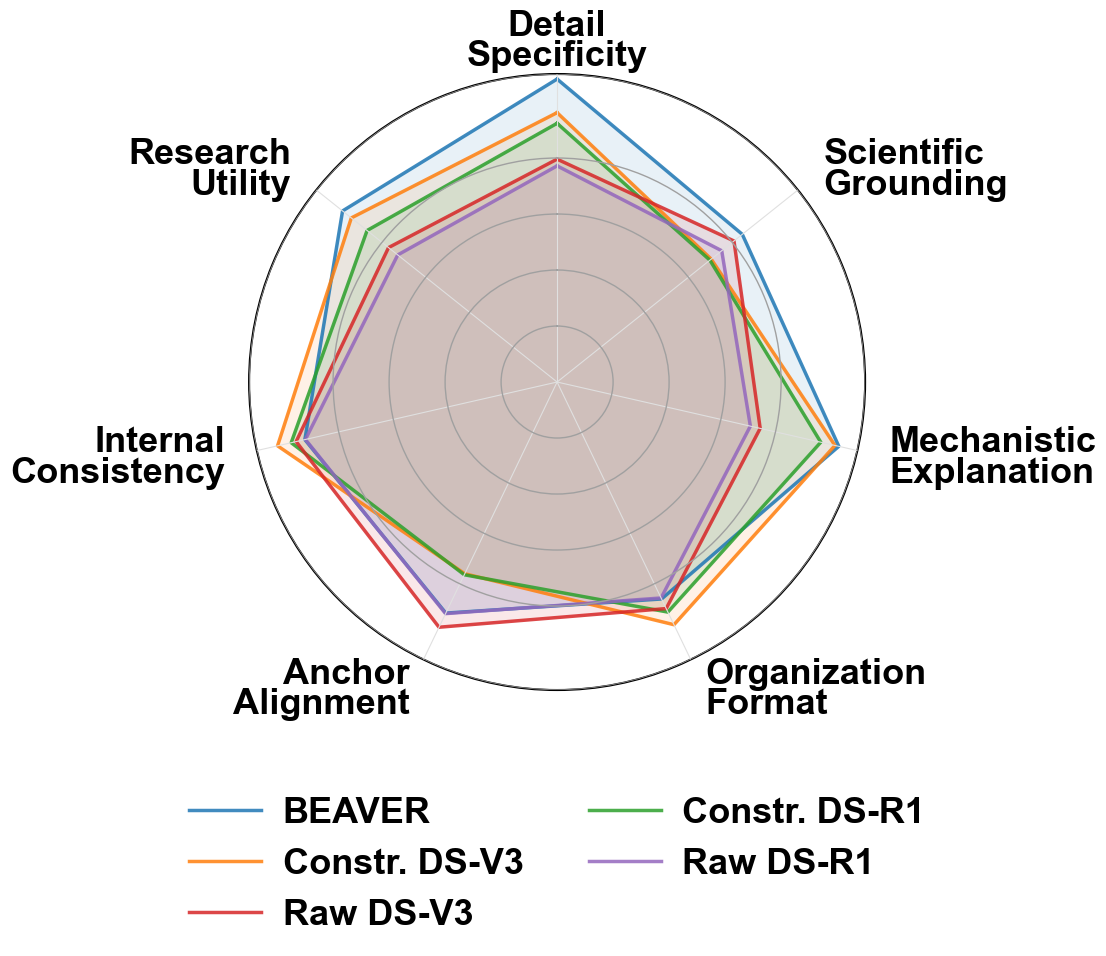

已保存叠加总图: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\combined_radar_5models.png


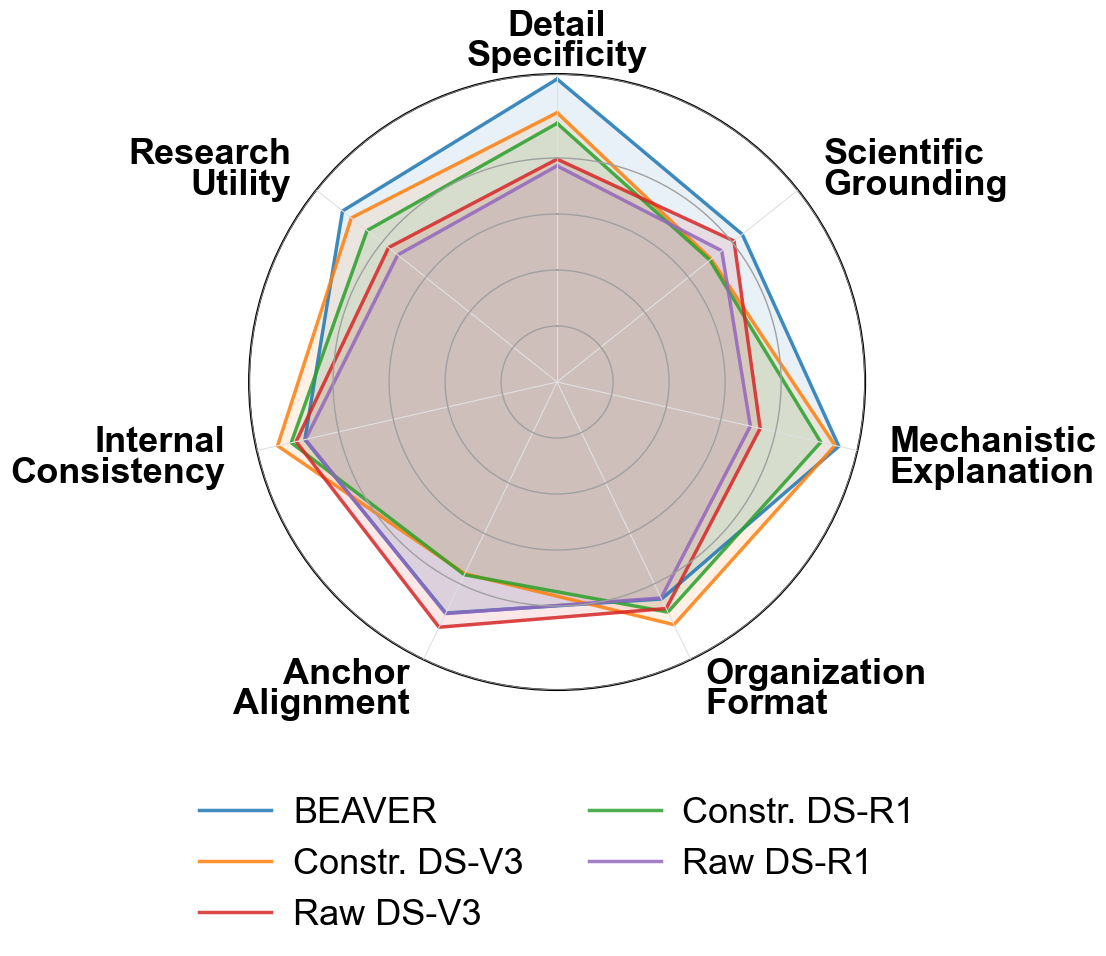

已保存叠加总图: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\combined_radar_5models.png


In [56]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 如果你在 Jupyter
%matplotlib inline

# =========================
# ===== 全局字号设置 =====
# =========================
FS_TITLE = 30  # 标题字号
FS_AXIS = 26  # 属性标签字号
FW = "bold"

# =========================
# ===== 全局风格 =====
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 1.5

# =========================
# ===== 路径设置 =====
# =========================
RESULT_ROOT = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

CSV_FILE = os.path.join(RESULT_ROOT, "3_final_scores_avg.csv")

OUT_DIR = os.path.join(RESULT_ROOT, "plots")
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# ===== 7个属性列 =====
# =========================
METRIC_COLUMNS = [
    "Detail_Specificity",
    "Scientific_Grounding",
    "Mechanistic_Explanation",
    "Organization_Format_Quality",
    "Anchor_Alignment",
    "Internal_Consistency",
    "Research_Utility",
]

# 显示名称：缩短一点，避免糊住
PRETTY_METRIC_NAMES = {
    "Detail_Specificity": "Detail\nSpecificity",
    "Scientific_Grounding": "Scientific\nGrounding",
    "Mechanistic_Explanation": "Mechanistic\nExplanation",
    "Organization_Format_Quality": "Organization\nFormat",
    "Anchor_Alignment": "Anchor\nAlignment",
    "Internal_Consistency": "Internal\nConsistency",
    "Research_Utility": "Research\nUtility",
}

# 5个模型顺序
#PREFERRED_MODEL_ORDER = [
#    "BEAVER_NoQualityLoop",
#    "Constrained_DeepSeek-V3",
#    "Constrained_DeepSeek-R1",
#    "Constrained_Qwen-Max",
#    "Constrained_Kimi",
#    "Raw_DeepSeek-V3",
#    "Raw_DeepSeek-R1",
#    "Raw_Qwen-Max",
#    "Raw_Kimi",
#]

# 现在的模型顺序（只保留5个）
PREFERRED_MODEL_ORDER = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-V3",
    "Raw_DeepSeek-R1",
]


# 显示标题
MODEL_LABEL_MAP = {
    "BEAVER_NoQualityLoop": "BEAVER",
    "Constrained_DeepSeek-V3": "Constr. DS-V3",
    "Constrained_DeepSeek-R1": "Constr. DS-R1",
    "Constrained_Qwen-Max": "Constr. Qwen",
    "Constrained_Kimi": "Constr. Kimi",
    "Raw_DeepSeek-V3": "Raw DS-V3",
    "Raw_DeepSeek-R1": "Raw DS-R1",
    "Raw_Qwen-Max": "Raw Qwen",
    "Raw_Kimi": "Raw Kimi",
}

# 每个模型一个颜色
MODEL_COLOR_MAP = {
    "BEAVER_NoQualityLoop": "#1f77b4",
    "Constrained_DeepSeek-V3": "#ff7f0e",
    "Constrained_DeepSeek-R1": "#2ca02c",
    "Raw_DeepSeek-V3": "#d62728",
    "Raw_DeepSeek-R1": "#9467bd",
}

# =========================
# ===== 工具函数 =====
# =========================

EXCLUDE_MODEL_KEYWORDS = ["Qwen", "Kimi"]

def filter_excluded_models(df: pd.DataFrame) -> pd.DataFrame:
    """Strictly keep only PREFERRED_MODEL_ORDER and remove Kimi/Qwen rows.

    这样即使 avg CSV 里还残留 Kimi/Qwen，或后面 cell 直接读取旧 CSV，
    绘图时也只会保留 5 个指定模型。
    """
    if "Model" not in df.columns:
        return df.copy()

    out = df.copy()

    # 1) 强制只保留目标 5 个模型，比仅按关键词排除更稳。
    out = out[out["Model"].astype(str).isin(PREFERRED_MODEL_ORDER)].copy()

    # 2) 双保险：排除任何名称中包含 Qwen/Kimi 的模型。
    pattern = "|".join(EXCLUDE_MODEL_KEYWORDS)
    mask = ~out["Model"].astype(str).str.contains(pattern, case=False, regex=True, na=False)
    out = out.loc[mask].copy()

    return out

def load_data(csv_file):
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"找不到文件: {csv_file}")

    df = pd.read_csv(csv_file, encoding="utf-8-sig")
    df = filter_excluded_models(df)

    if "Model" not in df.columns:
        raise ValueError("CSV 至少需要包含 Model 列")

    for col in METRIC_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"缺少列: {col}")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    order_map = {m: i for i, m in enumerate(PREFERRED_MODEL_ORDER)}
    df["_order"] = df["Model"].map(order_map).fillna(999)
    df = df.sort_values("_order").drop(columns=["_order"]).reset_index(drop=True)

    return df

def prettify_model_name(name):
    return MODEL_LABEL_MAP.get(name, name)

def close_polygon(vals):
    return np.r_[vals, vals[0]]

def radar_angles(n):
    ang = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.r_[ang, ang[0]]

def format_xtick_alignment(ax, angles):
    labels = ax.get_xticklabels()
    for angle, label in zip(angles[:-1], labels):
        deg = np.degrees(angle)

        if np.isclose(deg, 0) or np.isclose(deg, 180):
            ha = "center"
        elif 0 < deg < 180:
            ha = "left"
        else:
            ha = "right"

        label.set_horizontalalignment(ha)
        label.set_verticalalignment("center")
        label.set_linespacing(0.9)

def style_radar_ax(ax, category_labels):
    n = len(category_labels)
    ang = radar_angles(n)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(ang[:-1])
    ax.set_xticklabels(
        category_labels,
        fontsize=FS_AXIS,
        fontweight=FW,
    )
    ax.tick_params(axis="x", pad=8)

    # 分数范围（保持你的设置）
    ax.set_ylim(4, 9.5)
    ax.set_yticks([5, 6, 7, 8, 9.5])
    ax.set_yticklabels([])

    # ====================
    # 【核心修改区：网格风格】
    # ====================
    # 1. 稍微加深一点同心圆（y轴）的颜色，加粗一点点，让它更清晰
    ax.yaxis.grid(True, color="#A0A0A0", lw=1.0) 
    ax.xaxis.grid(True, color="#E0E0E0", lw=0.8)

    # 2. 【最关键的一行】：强制网格线显示在数据图层（线条和填充）的上方！
    ax.set_axisbelow(False)
    # ====================

    # 极坐标外圈去掉
    ax.set_facecolor("white") 

    format_xtick_alignment(ax, ang)

# =========================
# ===== 绘图逻辑 =====
# =========================

def draw_single_model_radar(ax, row):
    """绘制单个模型的雷达图（含填充）"""
    labels = [PRETTY_METRIC_NAMES[c] for c in METRIC_COLUMNS]
    ang = radar_angles(len(METRIC_COLUMNS))

    style_radar_ax(ax, labels)

    model = row["Model"]
    vals = row[METRIC_COLUMNS].astype(float).values
    vals = close_polygon(vals)

    color = MODEL_COLOR_MAP.get(model, "#999999")

    ax.plot(
        ang, vals,
        color=color,
        lw=2.0,
        alpha=0.90,
    )
    ax.fill(
        ang, vals,
        color=color,
        alpha=0.18,  # 单图的填充透明度
    )

    ax.set_title(
        prettify_model_name(model),
        fontsize=FS_TITLE,
        fontweight=FW,
        pad=14,
    )



def cleanup_excluded_radar_files(out_dir):
    """删除旧的 Kimi/Qwen 雷达图文件，避免你在文件夹里看到历史图片。"""
    targets = [out_dir, os.path.join(out_dir, "individual_radars")]
    removed = []
    for folder in targets:
        if not os.path.isdir(folder):
            continue
        for fn in os.listdir(folder):
            low = fn.lower()
            if any(k.lower() in low for k in EXCLUDE_MODEL_KEYWORDS) and (low.endswith(".png") or low.endswith(".pdf") or low.endswith(".svg")):
                path = os.path.join(folder, fn)
                try:
                    os.remove(path)
                    removed.append(path)
                except OSError:
                    pass
    if removed:
        print("已删除旧的 Kimi/Qwen 雷达图文件:")
        for p in removed:
            print("  ", p)

def plot_individual_radars(df, out_dir, show_in_notebook=False):
    """任务1：输出一个文件夹下5张单独的图"""
    individual_dir = os.path.join(out_dir, "individual_radars")
    os.makedirs(individual_dir, exist_ok=True)
    
    print(f"开始生成单图，保存路径: {individual_dir}")
    
    for _, row in df.iterrows():
        model = row["Model"]
        
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
        # fig.patch.set_facecolor("#EFEFEF") # Removed gray figure background
        fig.patch.set_facecolor("white") # Set figure background to white
        ax.set_facecolor("white") # Set axes background to white
        
        draw_single_model_radar(ax, row)
        
        safe_model_name = model.replace("/", "_").replace("\\", "_")
        out_file = os.path.join(individual_dir, f"{safe_model_name}_radar.png")
        
        plt.savefig(
            out_file,
            dpi=600,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )
        
        if show_in_notebook:
            plt.show()
        
        plt.close(fig)
        print(f"已保存: {out_file}")


def plot_combined_radar(df, out_dir, show_in_notebook=True):
    """任务2：将5个模型叠放在一张雷达图里"""
    print(f"\n开始生成叠加总图，保存路径: {out_dir}")
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    # fig.patch.set_facecolor("#EFEFEF") # Removed gray figure background
    fig.patch.set_facecolor("white") # Set figure background to white
    ax.set_facecolor("white") # Set axes background to white

    labels = [PRETTY_METRIC_NAMES[c] for c in METRIC_COLUMNS]
    ang = radar_angles(len(METRIC_COLUMNS))

    style_radar_ax(ax, labels)
    
    ax.set_title("", fontsize=FS_TITLE+2, fontweight=FW, pad=30)

    # 循环叠加 5 条线和填充
    for _, row in df.iterrows():
        model = row["Model"]
        vals = row[METRIC_COLUMNS].astype(float).values
        vals = close_polygon(vals)

        color = MODEL_COLOR_MAP.get(model, "#999999")

        # 画线
        ax.plot(
            ang, vals,
            color=color,
            lw=2.5,
            alpha=0.85,
            label=prettify_model_name(model),
        )
        
        # 画填充区（透明度设低一点，防止叠在一起太乱）
        ax.fill(
            ang, vals,
            color=color,
            alpha=0.10,  
        )
    
    # 将图例放在最下方
    # 先拿到当前图里的 handles 和 labels
    handles, labels = ax.get_legend_handles_labels()
    
    # 按你想要的“列顺序”手动排序
    desired_order = [
        "BEAVER",
        "Constr. DS-V3",
        "Raw DS-V3",
        "Constr. DS-R1",
        "Raw DS-R1",
    ]
    
    ordered_handles = []
    ordered_labels = []
    
    for target in desired_order:
        for h, l in zip(handles, labels):
            if l == target:
                ordered_handles.append(h)
                ordered_labels.append(l)
                break
    
    # 两列显示
    ax.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        fontsize=26,
        frameon=False,
        columnspacing=1.8,
        handletextpad=0.6,
    )

    out_file = os.path.join(out_dir, "combined_radar_5models.png")
    plt.savefig(
        out_file,
        dpi=600,
        bbox_inches="tight", # 这个参数会自动扩展画布，保证图例不会被裁切
        facecolor=fig.get_facecolor(),
    )

    if show_in_notebook:
        plt.show()
    else:
        plt.close(fig)

    print(f"已保存叠加总图: {out_file}")


# =========================
# ===== 主程序 =====
# =========================
if __name__ == "__main__":
    df = load_data(CSV_FILE)
    print("雷达图实际绘制模型:", list(df["Model"]))
    assert not df["Model"].astype(str).str.contains("Qwen|Kimi", case=False, regex=True, na=False).any(), "雷达图数据中仍包含 Qwen/Kimi"
    
    if 'display' in globals():
        display(df[["Model"] + METRIC_COLUMNS])
    else:
        print(df[["Model"] + METRIC_COLUMNS].head())
        
    # 1. 清理旧图，避免文件夹里还残留 Kimi/Qwen 雷达图
    cleanup_excluded_radar_files(OUT_DIR)

    # 2. 批量生成 5 张单图
    plot_individual_radars(df, OUT_DIR, show_in_notebook=False)
    
    # 3. 生成 1 张带填充的叠加总图
    plot_combined_radar(df, OUT_DIR, show_in_notebook=True)

,Model,Detail_Specificity,Scientific_Grounding,Mechanistic_Explanation,Organization_Format_Quality,Anchor_Alignment,Internal_Consistency,Research_Utility,Overall,JudgeParseOK(%),InvalidAnswer(%),ScoredItems,Coverage(%),Overall_from_4_12,Overall_from_5_12
0,BEAVER_NoQualityLoop,9.41,8.23,9.16,8.30,8.58,8.62,8.90,8.77,100.0,0.0,111.0,100.0,8.99,8.55
1,Constrained_DeepSeek-V3,8.81,7.52,9.09,8.81,7.80,9.12,8.70,8.42,100.0,0.0,111.0,100.0,8.26,8.59
2,Constrained_DeepSeek-R1,8.62,7.49,8.83,8.56,7.82,8.87,8.34,8.27,100.0,0.0,111.0,100.0,7.93,8.61
3,Raw_DeepSeek-V3,7.98,8.04,7.72,8.49,8.86,8.78,7.85,8.20,100.0,0.0,111.0,100.0,8.14,8.26
4,Raw_DeepSeek-R1,7.86,7.76,7.54,8.28,8.59,8.61,7.64,7.99,100.0,0.0,111.0,100.0,7.95,8.02


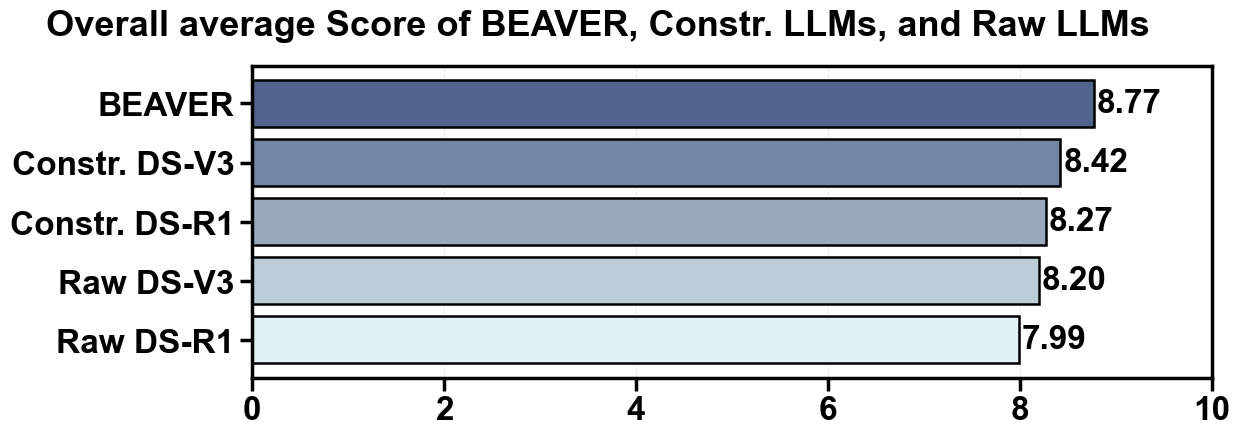

已保存: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\Overall_score_ranking_horizontal_gradient.png


In [57]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 如果你在 Jupyter 里，建议保留这一句
%matplotlib inline

# =========================
# ===== 全局字号设置 =====
# =========================
FS_TITLE = 26
FS_LABEL = 26
FS_TICK = 24
FS_ANNOT = 24

# =========================
# ===== 全局风格设置 =====
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 2.5
plt.rcParams["xtick.major.width"] = 2.5
plt.rcParams["ytick.major.width"] = 2.5
plt.rcParams["xtick.major.size"] = 9
plt.rcParams["ytick.major.size"] = 9
plt.rcParams["font.weight"] = "bold"         # 全局默认加粗
plt.rcParams["axes.titleweight"] = "bold"    # 标题加粗
plt.rcParams["axes.labelweight"] = "bold"    # 坐标轴标题加粗
# =========================
# ===== 布局可调参数 =====
# =========================
FIGSIZE_HBAR = (15, 4)
LEFT_HBAR = 0.34

# =========================
# ===== 路径设置 =====
# =========================
RESULT_ROOT = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

CSV_FILE = os.path.join(RESULT_ROOT, "3_final_scores_avg.csv")

OUT_DIR = os.path.join(RESULT_ROOT, "plots")
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# ===== 列设置 =====
# =========================
PREFERRED_MODEL_ORDER = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-V3",
    "Raw_DeepSeek-R1",
]

MODEL_LABEL_MAP = {
    "BEAVER_NoQualityLoop": "BEAVER",
    "Constrained_DeepSeek-V3": "Constr. DS-V3",
    "Raw_DeepSeek-V3": "Raw DS-V3",
    "Constrained_DeepSeek-R1": "Constr. DS-R1",
    "Raw_DeepSeek-R1": "Raw DS-R1",
    "Constrained_Qwen-Max": "Constr. Qwen",
    "Raw_Qwen-Max": "Raw Qwen",
    "Constrained_Kimi": "Constr. Kimi",
    "Raw_Kimi": "Raw Kimi",
}

# =========================
# ===== 配色：深 -> 浅 =====
# =========================
DARK_RGB = (80, 100, 140)
LIGHT_RGB = (225, 240, 240)

# =========================
# ===== 工具函数 =====
# =========================
def rgb255_to_01(rgb):
    return np.array(rgb) / 255.0

def make_gradient_colors(n, start_rgb=DARK_RGB, end_rgb=LIGHT_RGB):
    start = rgb255_to_01(start_rgb)
    end = rgb255_to_01(end_rgb)

    if n == 1:
        return [tuple(start)]

    colors = []
    for t in np.linspace(0, 1, n):
        c = start * (1 - t) + end * t
        colors.append(tuple(c))
    return colors

def prettify_model_name(name):
    return MODEL_LABEL_MAP.get(name, name)


EXCLUDE_MODEL_KEYWORDS = ["Qwen", "Kimi"]

def filter_excluded_models(df: pd.DataFrame) -> pd.DataFrame:
    """Strictly keep only PREFERRED_MODEL_ORDER and remove Kimi/Qwen rows.

    这样即使 avg CSV 里还残留 Kimi/Qwen，或后面 cell 直接读取旧 CSV，
    绘图时也只会保留 5 个指定模型。
    """
    if "Model" not in df.columns:
        return df.copy()

    out = df.copy()

    # 1) 强制只保留目标 5 个模型，比仅按关键词排除更稳。
    out = out[out["Model"].astype(str).isin(PREFERRED_MODEL_ORDER)].copy()

    # 2) 双保险：排除任何名称中包含 Qwen/Kimi 的模型。
    pattern = "|".join(EXCLUDE_MODEL_KEYWORDS)
    mask = ~out["Model"].astype(str).str.contains(pattern, case=False, regex=True, na=False)
    out = out.loc[mask].copy()

    return out

def get_padded_limits(vals, low_pad=0.15, high_pad=0.25, floor=0, ceil=10):
    vals = np.asarray(vals, dtype=float)
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    lo = max(floor, np.floor(vmin * 10) / 10 - low_pad)
    hi = min(ceil, np.ceil(vmax * 10) / 10 + high_pad)
    if hi <= lo:
        lo, hi = floor, ceil
    return lo, hi

def load_data(csv_file):
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"找不到文件: {csv_file}")

    df = pd.read_csv(csv_file, encoding="utf-8-sig")
    df = filter_excluded_models(df)

    if "Model" not in df.columns or "Overall" not in df.columns:
        raise ValueError("CSV 至少需要包含 Model 和 Overall 列")

    df["Overall"] = pd.to_numeric(df["Overall"], errors="coerce")

    order_map = {m: i for i, m in enumerate(PREFERRED_MODEL_ORDER)}
    df["_order"] = df["Model"].map(order_map).fillna(999)
    df = df.sort_values(["_order"]).drop(columns=["_order"]).reset_index(drop=True)

    return df

# =========================
# ===== 主绘图函数 =====
# =========================
def plot_overall_horizontal_bar(df, out_dir, show_in_notebook=True):
    df_plot = df.copy().sort_values("Overall", ascending=False).reset_index(drop=True)

    models = [prettify_model_name(m) for m in df_plot["Model"]]
    scores = df_plot["Overall"].values
    colors = make_gradient_colors(
        len(df_plot),
        start_rgb=DARK_RGB,
        end_rgb=LIGHT_RGB
    )

    fig, ax = plt.subplots(figsize=FIGSIZE_HBAR)

    bars = ax.barh(
        range(len(models)),
        scores,
        color=colors,
        edgecolor="black",
        linewidth=1.8,
        height=0.8
    )

    ax.set_title(
        "Overall average Score of BEAVER, Constr. LLMs, and Raw LLMs",
        fontsize=FS_TITLE,
        pad=22,
        fontweight="bold",
        x=0.36
    )
    ax.set_xlabel("", fontsize=FS_LABEL, labelpad=10)
    ax.set_ylabel("", fontsize=FS_LABEL, labelpad=10)

    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=FS_TICK)
    ax.tick_params(axis="x", labelsize=FS_TICK)

    ax.invert_yaxis()
    ax.set_xlim(0, 10)
    ax.grid(axis="x", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)

    for bar, val in zip(bars, scores):
        ax.text(
            bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            ha="left",
            fontsize=FS_ANNOT
        )

    fig.subplots_adjust(left=LEFT_HBAR, right=0.98, top=0.90, bottom=0.12)

    out_file = os.path.join(out_dir, "Overall_score_ranking_horizontal_gradient.png")
    plt.savefig(out_file, dpi=600, bbox_inches="tight")

    if show_in_notebook:
        plt.show()
    else:
        plt.close()

    print(f"已保存: {out_file}")

# =========================
# ===== 主程序 =====
# =========================
df = load_data(CSV_FILE)
display(df)
plot_overall_horizontal_bar(df, OUT_DIR, show_in_notebook=True)

In [58]:
import os
import pandas as pd

root = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

forward_path = os.path.join(root, "Forward", "3d_overall_by_question_structure_forward.csv")
reverse_path = os.path.join(root, "Reverse", "3d_overall_by_question_structure_reverse.csv")
out_path = os.path.join(root, "3d_overall_by_question_structure_forward_reverse_mean.csv")

df_f = pd.read_csv(forward_path)
df_r = pd.read_csv(reverse_path)

key = "QuestionStructure"

# 只保留两边共有的模型列
model_cols = [c for c in df_f.columns if c != key and c in df_r.columns]

df_f = df_f[[key] + model_cols].copy()
df_r = df_r[[key] + model_cols].copy()

merged = df_f.merge(df_r, on=key, how="inner", suffixes=("_forward", "_reverse"))

df_mean = merged[[key]].copy()
for m in model_cols:
    df_mean[m] = (
        merged[f"{m}_forward"].astype(float) +
        merged[f"{m}_reverse"].astype(float)
    ) / 2
    df_mean[m] = df_mean[m].round(3)

# 可选：固定结构顺序
structure_order = ["single", "single_with_facets", "multi_part"]
df_mean[key] = pd.Categorical(df_mean[key], categories=structure_order, ordered=True)
df_mean = df_mean.sort_values(key).reset_index(drop=True)

df_mean.to_csv(out_path, index=False, encoding="utf-8-sig")

print("Saved:", out_path)
print(df_mean)

Saved: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\3d_overall_by_question_structure_forward_reverse_mean.csv
    QuestionStructure  BEAVER_NoQualityLoop  Constrained_DeepSeek-R1  \
0              single                 8.982                    8.320   
1  single_with_facets                 8.535                    8.127   
2          multi_part                 8.795                    8.358   

   Constrained_DeepSeek-V3  Raw_DeepSeek-R1  Raw_DeepSeek-V3  
0                    8.543            7.904            7.980  
1                    8.216            8.129            8.346  
2                    8.515            7.924            8.272  


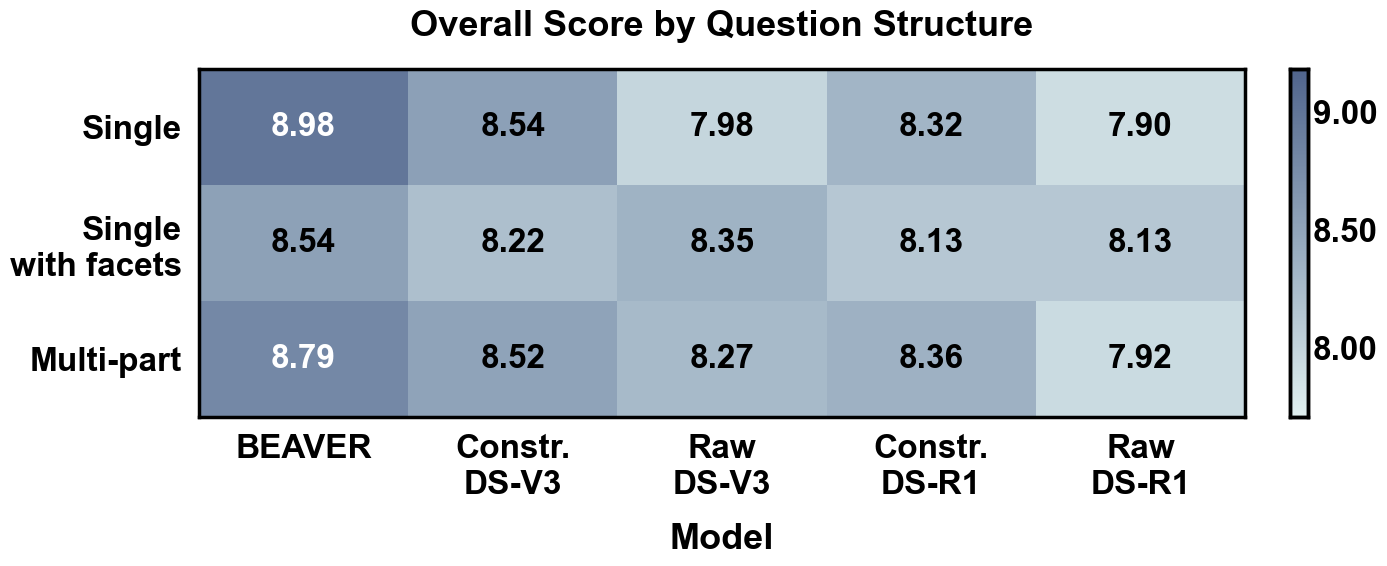

已保存: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\Question_structure_overall_heatmap_selected_models.png
已保存: C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\plots\Question_structure_overall_heatmap_selected_models.pdf


,BEAVER_NoQualityLoop,Constrained_DeepSeek-V3,Raw_DeepSeek-V3,Constrained_DeepSeek-R1,Raw_DeepSeek-R1
QuestionStructure,,,,,
single,8.982,8.543,7.980,8.320,7.904
single_with_facets,8.535,8.216,8.346,8.127,8.129
multi_part,8.795,8.515,8.272,8.358,7.924


In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FormatStrFormatter
# 如果你在 Jupyter 里，可以保留这一句
# %matplotlib inline

# =========================
# ===== 全局字号设置 =====
# =========================
FS_TITLE = 26
FS_LABEL = 26
FS_TICK = 24
FS_ANNOT = 24

# =========================
# ===== 全局风格设置 =====
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 2.5
plt.rcParams["xtick.major.width"] = 2.5
plt.rcParams["ytick.major.width"] = 2.5
plt.rcParams["xtick.major.size"] = 9
plt.rcParams["ytick.major.size"] = 9
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.grid"] = False

# 所有文字强制黑色
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

# =========================
# ===== 保存路径设置 =====
# =========================
RESULT_ROOT = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

OUT_DIR = os.path.join(RESULT_ROOT, "plots")
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# Question-structure overall heatmap
# Forward / Reverse mean
# Only selected models
# =========================

QUESTION_STRUCTURE_DISPLAY = {
    "single": "Single",
    "single-with-facets": "Single\nwith facets",
    "single_with_facets": "Single\nwith facets",
    "multi-part": "Multi-part",
    "multi_part": "Multi-part",
}

# 按指定顺序排列：
# BEAVER、Constrained DS-V3、Raw DS-V3、Constrained DS-R1、Raw DS-R1
MODEL_KEEP = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Raw_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-R1",
]

MODEL_LABEL_MAP = {
    "BEAVER_NoQualityLoop": "BEAVER",
    "Constrained_DeepSeek-V3": "Constr.\nDS-V3",
    "Raw_DeepSeek-V3": "Raw\nDS-V3",
    "Constrained_DeepSeek-R1": "Constr.\nDS-R1",
    "Raw_DeepSeek-R1": "Raw\nDS-R1",
}


def prettify_question_structure(x):
    x = str(x)
    return QUESTION_STRUCTURE_DISPLAY.get(x, x.replace("_", "-"))


def prettify_model_name(x):
    x = str(x)
    return MODEL_LABEL_MAP.get(x, x)


def plot_question_structure_heatmap(
    df_mean: pd.DataFrame,
    out_dir: str = OUT_DIR,
    show_in_notebook: bool = True,
):
    if df_mean.empty:
        print("No df_mean")
        return None

    # =========================
    # Build heatmap matrix
    # =========================
    heat_df = df_mean.copy()

    if "QuestionStructure" not in heat_df.columns:
        raise ValueError("df_mean must contain a 'QuestionStructure' column.")

    heat_df = heat_df.set_index("QuestionStructure")

    # =========================
    # Only keep selected model columns
    # =========================
    existing_models = [
        m for m in MODEL_KEEP
        if m in heat_df.columns
    ]

    missing_models = [
        m for m in MODEL_KEEP
        if m not in heat_df.columns
    ]

    if missing_models:
        print("Warning: missing models:", missing_models)

    if not existing_models:
        raise ValueError(
            "None of the selected models were found in df_mean columns. "
            "Please check column names."
        )

    # 这里会严格按照 MODEL_KEEP 的顺序排列列
    heat_df = heat_df[existing_models]

    # 只保留数值，避免非分数内容进入热图
    heat_df = heat_df.apply(pd.to_numeric, errors="coerce")

    # =========================
    # Question structure order
    # =========================
    qs_order = [
        "single",
        "single-with-facets",
        "single_with_facets",
        "multi-part",
        "multi_part",
    ]

    existing_order = [
        q for q in qs_order
        if q in heat_df.index
    ]

    other_rows = [
        q for q in heat_df.index
        if q not in existing_order
    ]

    heat_df = heat_df.loc[existing_order + other_rows]

    data = heat_df.values.astype(float)

    row_labels = [
        prettify_question_structure(x)
        for x in heat_df.index
    ]

    col_labels = [
        prettify_model_name(x)
        for x in heat_df.columns
    ]

    # =========================
    # Custom colormap
    # 与柱状图脚本风格一致：深蓝灰 -> 浅蓝灰
    # =========================
    LOW_COLOR = (225 / 255, 240 / 255, 240 / 255)
    MID_COLOR = (150 / 255, 170 / 255, 190 / 255)
    HIGH_COLOR = (80 / 255, 100 / 255, 140 / 255)

    clean_cmap = LinearSegmentedColormap.from_list(
        "custom_blue_gray_cmap",
        [LOW_COLOR, MID_COLOR, HIGH_COLOR]
    )

    # =========================
    # Color range
    # =========================
    USE_FIXED_RANGE = False
    FIXED_VMIN = 0
    FIXED_VMAX = 10

    finite_data = data[np.isfinite(data)]

    if finite_data.size == 0:
        raise ValueError("No finite numeric values found in selected model columns.")

    if USE_FIXED_RANGE:
        vmin, vmax = FIXED_VMIN, FIXED_VMAX
    else:
        data_min = np.nanmin(finite_data)
        data_max = np.nanmax(finite_data)

        pad = max(0.20, 0.12 * (data_max - data_min))
        vmin = max(0, data_min - pad)
        vmax = min(10, data_max + pad)

    # =========================
    # Plot
    # =========================
    fig, ax = plt.subplots(
        figsize=(14.5, max(6.0, 1.05 * len(row_labels) + 2.5))
    )

    im = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        cmap=clean_cmap,
        interpolation="none"
    )

    # =========================
    # Remove grid lines
    # =========================
    ax.grid(False)
    ax.xaxis.grid(False, which="both")
    ax.yaxis.grid(False, which="both")
    ax.set_axisbelow(False)

    # =========================
    # Axis ticks and labels
    # =========================
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(
        col_labels,
        ha="center",
        fontsize=FS_TICK,
        fontweight="bold",
        color="black"
    )

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(
        row_labels,
        fontsize=FS_TICK,
        fontweight="bold",
        color="black"
    )

    ax.set_xlabel(
        "Model",
        fontsize=FS_LABEL,
        fontweight="bold",
        labelpad=16,
        color="black"
    )

    ax.set_ylabel(
        "",
        fontsize=FS_LABEL,
        fontweight="bold",
        labelpad=16,
        color="black"
    )

    # 防止 minor grid
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)

    ax.tick_params(
        axis="x",
        which="both",
        length=0,
        labelsize=FS_TICK,
        width=2.5,
        colors="black",
        pad=12
    )

    ax.tick_params(
        axis="y",
        which="both",
        length=0,
        labelsize=FS_TICK,
        width=2.5,
        colors="black",
        pad=12
    )
    # =========================
    # Outer frame
    # =========================
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.5)
        spine.set_color("black")

    # =========================
    # Add values
    # 所有数字强制黑色
    # =========================
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if not np.isfinite(val):
                continue

            # 根据当前色块深浅自动决定数字颜色
            rgba = clean_cmap(im.norm(val))
            r, g, b = rgba[:3]

            # 计算背景亮度，越小表示越深
            luminance = 0.299 * r + 0.587 * g + 0.114 * b

            text_color = "white" if luminance < 0.55 else "black"

            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=FS_ANNOT,
                color=text_color,
                fontweight="bold"
            )

    # =========================
    # Colorbar
    # =========================
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.04
    )

    cbar.ax.tick_params(
        labelsize=FS_TICK,
        length=0,
        width=2.5,
        colors="black"
    )

    for label in cbar.ax.get_yticklabels():
        label.set_color("black")
        label.set_fontweight("bold")

    cbar.outline.set_visible(True)
    cbar.outline.set_linewidth(2.5)
    cbar.outline.set_edgecolor("black")
    cbar.formatter = FormatStrFormatter("%.2f")
    cbar.update_ticks()
    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.5)
        spine.set_color("black")

    # =========================
    # Title
    # =========================
    ax.set_title(
        "Overall Score by Question Structure",
        fontsize=FS_TITLE,
        fontweight="bold",
        pad=24,
        color="black"
    )

    # =========================
    # Layout
    # =========================
    fig.subplots_adjust(
        left=0.18,
        right=0.96,
        top=0.86,
        bottom=0.28
    )

    # =========================
    # Save figure
    # =========================
    out_png = os.path.join(
        out_dir,
        "Question_structure_overall_heatmap_selected_models.png"
    )

    out_pdf = os.path.join(
        out_dir,
        "Question_structure_overall_heatmap_selected_models.pdf"
    )

    fig.savefig(
        out_png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        out_pdf,
        bbox_inches="tight"
    )

    if show_in_notebook:
        plt.show()
    else:
        plt.close()

    print(f"已保存: {out_png}")
    print(f"已保存: {out_pdf}")

    return heat_df


question_structure_matrix = plot_question_structure_heatmap(
    df_mean,
    OUT_DIR,
    show_in_notebook=True
)

display(question_structure_matrix)

In [60]:
# -*- coding: utf-8 -*-
"""
统计不同 question_structure 下，各模型 7 个评价维度的平均分，并计算加权 Overall。

输入：
    1_raw_answers.csv
    2_item_scores.csv
    2_item_scores_倒.csv

输出：
    1_question_structure_7metrics_forward.csv
    2_question_structure_7metrics_reverse.csv
    3_question_structure_7metrics_bidirectional_mean.csv

说明：
    - forward：只统计正序评分文件 2_item_scores.csv
    - reverse：只统计倒序评分文件 2_item_scores_倒.csv
    - bidirectional mean：先对同一个 row_id + Model 的正序/倒序 7 个维度分别取平均，
      再计算加权 Overall，并按 question_structure 聚合。

重要：
    这里的 Overall 不是 7 个维度简单平均，而是和原始评分脚本一致的加权平均：
        Detail_Specificity: 0.18
        Scientific_Grounding: 0.20
        Mechanistic_Explanation: 0.16
        Organization_Format_Quality: 0.08
        Anchor_Alignment: 0.18
        Internal_Consistency: 0.08
        Research_Utility: 0.12
"""

import os
import numpy as np
import pandas as pd


# =========================
# 1. 路径设置
# =========================

ROOT_DIR = os.path.abspath(os.path.join("..", "Judge_output", "0723-后续返稿用这个"))

RAW_FILE = os.path.join(ROOT_DIR, "1_raw_answers.csv")
FWD_FILE = os.path.join(ROOT_DIR, "Forward", "2_item_scores_forward.csv")
REV_FILE = os.path.join(ROOT_DIR, "Reverse", "2_item_scores_reverse.csv")

OUT_DIR = os.path.join(ROOT_DIR, "question_structure_7metrics_summary")
os.makedirs(OUT_DIR, exist_ok=True)


# =========================
# 2. 评价维度与权重设置
# =========================

METRIC_COLUMNS = [
    "Detail_Specificity",
    "Scientific_Grounding",
    "Mechanistic_Explanation",
    "Organization_Format_Quality",
    "Anchor_Alignment",
    "Internal_Consistency",
    "Research_Utility",
]

# 与原始 Query 评分脚本保持一致的加权 Overall
WEIGHTS = {
    "Detail_Specificity": 0.18,
    "Scientific_Grounding": 0.20,
    "Mechanistic_Explanation": 0.16,
    "Organization_Format_Quality": 0.08,
    "Anchor_Alignment": 0.18,
    "Internal_Consistency": 0.08,
    "Research_Utility": 0.12,
}

# 检查权重是否加和为 1
weight_sum = sum(WEIGHTS.values())
if not np.isclose(weight_sum, 1.0):
    raise ValueError(f"WEIGHTS 权重加和不是 1，目前为 {weight_sum}")


# 输出排序用
QUESTION_STRUCTURE_ORDER = [
    "single",
    "single_with_facets",
    "multi_part",
]

# 只保留这些模型
MODEL_ORDER = [
    "BEAVER_NoQualityLoop",
    "Constrained_DeepSeek-V3",
    "Raw_DeepSeek-V3",
    "Constrained_DeepSeek-R1",
    "Raw_DeepSeek-R1",
]

MODEL_LABEL_MAP = {
    "BEAVER_NoQualityLoop": "BEAVER",
    "Constrained_DeepSeek-V3": "Constrained DS-V3",
    "Raw_DeepSeek-V3": "Raw DS-V3",
    "Constrained_DeepSeek-R1": "Constrained DS-R1",
    "Raw_DeepSeek-R1": "Raw DS-R1",
}


# =========================
# 3. 工具函数
# =========================

def read_csv_safely(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件: {path}")
    return pd.read_csv(path, encoding="utf-8-sig")


def prepare_raw(raw_df):
    """
    raw answers 中没有 row_id 列时，用原始行号生成 row_id。
    评分文件里的 row_id 通常就是 0,1,2,... 对应 raw_answers 的行号。
    """
    raw_df = raw_df.copy()

    if "row_id" not in raw_df.columns:
        raw_df = raw_df.reset_index().rename(columns={"index": "row_id"})

    if "question_structure" not in raw_df.columns:
        raise ValueError("1_raw_answers.csv 中缺少 question_structure 列。")

    keep_cols = ["row_id", "question_structure"]

    if "id" in raw_df.columns:
        keep_cols.append("id")

    if "question" in raw_df.columns:
        keep_cols.append("question")

    return raw_df[keep_cols].copy()


def prepare_score(score_df, score_name):
    """
    清洗单个评分文件。
    """
    score_df = score_df.copy()

    required_cols = ["row_id", "Model"] + METRIC_COLUMNS
    missing_cols = [c for c in required_cols if c not in score_df.columns]
    if missing_cols:
        raise ValueError(f"{score_name} 缺少必要列: {missing_cols}")

    # 只保留目标模型
    score_df = score_df[score_df["Model"].isin(MODEL_ORDER)].copy()

    # 转成数值
    for c in METRIC_COLUMNS:
        score_df[c] = pd.to_numeric(score_df[c], errors="coerce")

    return score_df


def calc_weighted_overall(df):
    """
    按 WEIGHTS 计算加权 Overall。
    """
    overall = np.zeros(len(df), dtype=float)

    for metric, weight in WEIGHTS.items():
        overall += df[metric].astype(float).values * weight

    return overall


def summarize_by_question_structure(score_df, raw_info, setting_name):
    """
    统计某一个 setting 下：
    question_structure × Model 的 7 个维度平均分 + 加权 Overall。
    """
    df = score_df.merge(
        raw_info,
        on="row_id",
        how="left"
    )

    if df["question_structure"].isna().any():
        n_missing = df["question_structure"].isna().sum()
        print(f"Warning: {setting_name} 中有 {n_missing} 行没有匹配到 question_structure。")

    # 关键修改：
    # 原来是 7 维简单平均：
    # df["Overall_from_7metrics"] = df[METRIC_COLUMNS].mean(axis=1)
    #
    # 现在改成与原始评分脚本一致的加权 Overall：
    df["Overall"] = calc_weighted_overall(df)

    summary = (
        df
        .groupby(["question_structure", "Model"], as_index=False)
        .agg(
            n_items=("row_id", "nunique"),
            **{c: (c, "mean") for c in METRIC_COLUMNS},
            Overall=("Overall", "mean")
        )
    )

    summary.insert(0, "Setting", setting_name)

    # 模型标签
    summary["Model_Label"] = summary["Model"].map(MODEL_LABEL_MAP).fillna(summary["Model"])

    # 排序
    summary["question_structure"] = pd.Categorical(
        summary["question_structure"],
        categories=QUESTION_STRUCTURE_ORDER,
        ordered=True
    )

    summary["Model"] = pd.Categorical(
        summary["Model"],
        categories=MODEL_ORDER,
        ordered=True
    )

    summary = (
        summary
        .sort_values(["question_structure", "Model"])
        .reset_index(drop=True)
    )

    # 列顺序
    summary = summary[
        [
            "Setting",
            "question_structure",
            "Model",
            "Model_Label",
            "n_items",
        ]
        + METRIC_COLUMNS
        + ["Overall"]
    ]

    return summary


def make_bidirectional_mean(fwd_df, rev_df):
    """
    对同一个 row_id + Model 的正序和倒序 7 个维度分别取平均。
    注意：
    - 这里先平均 7 个维度；
    - 后面 summarize_by_question_structure() 会基于平均后的 7 个维度计算加权 Overall。
    """
    key_cols = ["row_id", "Model"]

    fwd_small = fwd_df[key_cols + METRIC_COLUMNS].copy()
    rev_small = rev_df[key_cols + METRIC_COLUMNS].copy()

    merged = fwd_small.merge(
        rev_small,
        on=key_cols,
        how="inner",
        suffixes=("_forward", "_reverse")
    )

    expected_rows = len(set(fwd_df["row_id"])) * len(MODEL_ORDER)
    if merged.shape[0] != expected_rows:
        print(
            f"Warning: 双向合并后行数为 {merged.shape[0]}，"
            f"理论期望约为 {expected_rows}。可能存在正序/倒序缺失或模型不一致。"
        )

    out = merged[key_cols].copy()

    for c in METRIC_COLUMNS:
        out[c] = (
            merged[f"{c}_forward"] + merged[f"{c}_reverse"]
        ) / 2.0

    return out


# =========================
# 4. 主程序
# =========================

def main():
    raw = read_csv_safely(RAW_FILE)
    fwd = read_csv_safely(FWD_FILE)
    rev = read_csv_safely(REV_FILE)

    raw_info = prepare_raw(raw)
    fwd = prepare_score(fwd, "forward score file")
    rev = prepare_score(rev, "reverse score file")

    # ---------- 正序统计 ----------
    summary_forward = summarize_by_question_structure(
        score_df=fwd,
        raw_info=raw_info,
        setting_name="Forward"
    )

    # ---------- 倒序统计 ----------
    summary_reverse = summarize_by_question_structure(
        score_df=rev,
        raw_info=raw_info,
        setting_name="Reverse"
    )

    # ---------- 双向平均统计 ----------
    bidirectional_df = make_bidirectional_mean(fwd, rev)

    summary_bidirectional = summarize_by_question_structure(
        score_df=bidirectional_df,
        raw_info=raw_info,
        setting_name="Bidirectional mean"
    )

    # ---------- 保存 ----------
    out_forward = os.path.join(
        OUT_DIR,
        "1_question_structure_7metrics_forward.csv"
    )
    out_reverse = os.path.join(
        OUT_DIR,
        "2_question_structure_7metrics_reverse.csv"
    )
    out_bidirectional = os.path.join(
        OUT_DIR,
        "3_question_structure_7metrics_bidirectional_mean.csv"
    )

    summary_forward.round(3).to_csv(
        out_forward,
        index=False,
        encoding="utf-8-sig"
    )

    summary_reverse.round(3).to_csv(
        out_reverse,
        index=False,
        encoding="utf-8-sig"
    )

    summary_bidirectional.round(3).to_csv(
        out_bidirectional,
        index=False,
        encoding="utf-8-sig"
    )

    print("\nDone.")
    print(f"Saved forward summary:        {out_forward}")
    print(f"Saved reverse summary:        {out_reverse}")
    print(f"Saved bidirectional summary:  {out_bidirectional}")

    print("\n=== Forward summary preview ===")
    print(summary_forward.round(3).to_string(index=False))

    print("\n=== Reverse summary preview ===")
    print(summary_reverse.round(3).to_string(index=False))

    print("\n=== Bidirectional mean summary preview ===")
    print(summary_bidirectional.round(3).to_string(index=False))


if __name__ == "__main__":
    main()


Done.
Saved forward summary:        C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\question_structure_7metrics_summary\1_question_structure_7metrics_forward.csv
Saved reverse summary:        C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\question_structure_7metrics_summary\2_question_structure_7metrics_reverse.csv
Saved bidirectional summary:  C:\Users\user\FXR-水凝胶\2026-BEAVER-提交\EVAL\Query\Judge_output\0723-后续返稿用这个\question_structure_7metrics_summary\3_question_structure_7metrics_bidirectional_mean.csv

=== Forward summary preview ===
Setting question_structure                   Model       Model_Label  n_items  Detail_Specificity  Scientific_Grounding  Mechanistic_Explanation  Organization_Format_Quality  Anchor_Alignment  Internal_Consistency  Research_Utility  Overall
Forward             single    BEAVER_NoQualityLoop            BEAVER       37               9.538                 8.800                    9.505                  